In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import numpy as np
import tensorflow as tf
import librosa
import pickle
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy.signal as signal

In [48]:
# # Use these lines to check for tensorflow version and ensure we're using eager execution
# print(f"TensorFlow Version: {tf.__version__}")
# print(f"Eager Execution Enabled: {tf.executing_eagerly()}")

# # Load the model (we'll reuse your code)
# with open('results/CNN_model.json', 'r') as json_file:
#     loaded_model_json = json_file.read()
# loaded_model = tf.keras.models.model_from_json(loaded_model_json)
# loaded_model.load_weights("results/best_model.weights.h5")
# loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# # Load scaler & encoder
# with open("results/scaler.pickle", "rb") as f:
#     scaler = pickle.load(f)
# with open("results/encoder.pickle", "rb") as f:
#     encoder = pickle.load(f)

# # Feature extraction functions
# def zcr(data, frame_length, hop_length):
#     zcr = librosa.feature.zero_crossing_rate(data, frame_length=frame_length, hop_length=hop_length)
#     return np.squeeze(zcr)

# def rmse(data, frame_length=2048, hop_length=512):
#     rmse = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
#     return np.squeeze(rmse)

# def mfcc(data, sr, frame_length=2048, hop_length=512, flatten=True):
#     mfcc_result = librosa.feature.mfcc(y=data, sr=sr, n_fft=frame_length, hop_length=hop_length)
#     return np.squeeze(mfcc_result.T) if not flatten else np.ravel(mfcc_result.T)

# def extract_features(data, sr=22050, frame_length=2048, hop_length=512):
#     result = np.array([])
#     result = np.hstack((
#         result, 
#         zcr(data, frame_length, hop_length),
#         rmse(data, frame_length, hop_length),
#         mfcc(data, sr, frame_length, hop_length)
#     ))
#     return result

# def get_features_tensor(audio_data, sr=22050, expected_shape=(1, 2376)):
#     res = extract_features(audio_data, sr)
    
#     # Reshape or pad to match expected shape
#     flat_size = np.prod(expected_shape)
#     if res.size < flat_size:
#         pad_width = (0, flat_size - res.size)
#         res = np.pad(res, pad_width=pad_width, mode='constant')
#     else:
#         res = np.resize(res, expected_shape)
    
#     i_result = scaler.transform(res.reshape(1, -1))
#     final_result = np.expand_dims(i_result, axis=2)
#     return final_result

# # Get label names
# label_names = list(encoder.categories_[0])

# # A completely different approach using numerical optimization
# def generate_adversarial_audio_numerical(target_emotion, iterations=1000, sr=22050, duration=2.5, step_size=0.01):
#     """
#     Generate audio that maximizes the probability of a specific emotion using numerical optimization
#     """
#     print(f"Generating adversarial audio for emotion: {target_emotion}")
    
#     # Get the index of the target emotion
#     target_emotion_index = label_names.index(target_emotion)
    
#     # Initialize audio with Gaussian noise
#     num_samples = int(sr * duration)
#     audio_data = np.random.normal(0, 0.1, num_samples).astype(np.float32)
    
#     # Keep track of the confidence scores
#     confidence_history = []
    
#     # Define a function to evaluate the audio
#     def evaluate_audio(audio):
#         features = get_features_tensor(audio, sr)
#         predictions = loaded_model.predict(features, verbose=0)
#         confidence = predictions[0, target_emotion_index]
#         return confidence, predictions
    
#     # Optimization loop
#     for i in tqdm(range(iterations)):
#         # Get current confidence
#         current_confidence, predictions = evaluate_audio(audio_data)
        
#         if i % 50 == 0 or i == iterations - 1:
#             confidence_history.append(current_confidence)
#             print(f"Iteration {i}, Confidence: {current_confidence:.4f}")
        
#         # Try random perturbations and keep the best one
#         best_confidence = current_confidence
#         best_audio = audio_data.copy()
        
#         # Try 10 random perturbations
#         for _ in range(10):
#             # Create a perturbation
#             perturbation = np.random.normal(0, step_size, audio_data.shape)
#             perturbed_audio = audio_data + perturbation
#             perturbed_audio = np.clip(perturbed_audio, -1.0, 1.0)
            
#             # Evaluate the perturbed audio
#             new_confidence, _ = evaluate_audio(perturbed_audio)
            
#             # Keep the best perturbation
#             if new_confidence > best_confidence:
#                 best_confidence = new_confidence
#                 best_audio = perturbed_audio
        
#         # Update audio
#         audio_data = best_audio
        
#         # Reduce step size over time to refine the solution
#         if (i + 1) % 100 == 0:
#             step_size *= 0.9
    
#     # Get the final predictions
#     _, predictions = evaluate_audio(audio_data)
    
#     print("\nFinal Confidence Scores:")
#     for i, emotion in enumerate(label_names):
#         print(f"{emotion}: {predictions[0, i]:.4f}")
    
#     # Save the audio
#     output_filename = f"adversarial_{target_emotion}.wav"
#     sf.write(output_filename, audio_data, sr)
#     print(f"Audio saved as {output_filename}")
    
#     # Plot the confidence history
#     iterations_recorded = len(confidence_history)
#     x_points = np.linspace(0, iterations, iterations_recorded)
    
#     plt.figure(figsize=(10, 6))
#     plt.plot(x_points, confidence_history)
#     plt.xlabel('Iteration')
#     plt.ylabel('Confidence')
#     plt.title(f'Confidence in {target_emotion} over iterations')
#     plt.grid(True)
#     plt.savefig(f"confidence_history_{target_emotion}.png")
#     plt.close()
    
#     return audio_data, confidence_history


# # Yet another approach - using a genetic algorithm
# def generate_adversarial_audio_genetic(target_emotion, generations=50, population_size=20, sr=22050, duration=2.5):
#     """
#     Generate audio that maximizes the probability of a specific emotion using a genetic algorithm
#     """
#     print(f"Generating adversarial audio for emotion: {target_emotion} using genetic algorithm")
    
#     # Get the index of the target emotion
#     target_emotion_index = label_names.index(target_emotion)
    
#     # Initialize population with random audio samples
#     num_samples = int(sr * duration)
#     population = [np.random.normal(0, 0.1, num_samples).astype(np.float32) for _ in range(population_size)]
    
#     # Keep track of the best confidence score
#     best_confidence = 0
#     best_audio = None
#     confidence_history = []
    
#     # Define fitness function (confidence score for target emotion)
#     def fitness(audio):
#         features = get_features_tensor(audio, sr)
#         predictions = loaded_model.predict(features, verbose=0)
#         return predictions[0, target_emotion_index]
    
#     # Evolution loop
#     for gen in tqdm(range(generations)):
#         # Evaluate fitness for each individual
#         fitnesses = [fitness(ind) for ind in population]
        
#         # Find best individual
#         max_fitness_idx = np.argmax(fitnesses)
#         current_best_fitness = fitnesses[max_fitness_idx]
#         current_best_audio = population[max_fitness_idx]
        
#         # Update best overall
#         if current_best_fitness > best_confidence:
#             best_confidence = current_best_fitness
#             best_audio = current_best_audio.copy()
        
#         # Record progress
#         confidence_history.append(best_confidence)
#         print(f"Generation {gen}, Best Confidence: {best_confidence:.4f}")
        
#         # Select parents (tournament selection)
#         def tournament_selection(fitnesses, k=3):
#             idx1 = np.random.randint(0, len(fitnesses))
#             for _ in range(k-1):
#                 idx2 = np.random.randint(0, len(fitnesses))
#                 if fitnesses[idx2] > fitnesses[idx1]:
#                     idx1 = idx2
#             return idx1
        
#         # Create new population
#         new_population = []
        
#         # Elitism: keep the best individual
#         new_population.append(current_best_audio)
        
#         # Create the rest through crossover and mutation
#         for _ in range(population_size - 1):
#             # Select parents
#             parent1_idx = tournament_selection(fitnesses)
#             parent2_idx = tournament_selection(fitnesses)
            
#             # Crossover
#             crossover_point = np.random.randint(0, num_samples)
#             child = np.concatenate([population[parent1_idx][:crossover_point], 
#                                     population[parent2_idx][crossover_point:]])
            
#             # Mutation
#             mutation_rate = 0.05
#             mutation_mask = np.random.random(num_samples) < mutation_rate
#             mutation_values = np.random.normal(0, 0.1, num_samples)
#             child[mutation_mask] += mutation_values[mutation_mask]
            
#             # Ensure valid audio
#             child = np.clip(child, -1.0, 1.0)
            
#             new_population.append(child)
        
#         # Replace old population
#         population = new_population
    
#     # Evaluate the final best individual
#     features = get_features_tensor(best_audio, sr)
#     predictions = loaded_model.predict(features, verbose=0)
    
#     print("\nFinal Confidence Scores:")
#     for i, emotion in enumerate(label_names):
#         print(f"{emotion}: {predictions[0, i]:.4f}")
    
#     # Save the audio
#     output_filename = f"adversarial_{target_emotion}_genetic.wav"
#     sf.write(output_filename, best_audio, sr)
#     print(f"Audio saved as {output_filename}")
    
#     # Plot the confidence history
#     plt.figure(figsize=(10, 6))
#     plt.plot(confidence_history)
#     plt.xlabel('Generation')
#     plt.ylabel('Confidence')
#     plt.title(f'Confidence in {target_emotion} over generations')
#     plt.grid(True)
#     plt.savefig(f"confidence_history_{target_emotion}_genetic.png")
#     plt.close()
    
#     return best_audio, confidence_history


# # Example usage
# if __name__ == "__main__":
#     # List available emotions
#     print("Available emotions:", label_names)
    
#     # Ask user which emotion to generate
#     target_emotion = input("Enter the target emotion: ")
#     if target_emotion not in label_names:
#         print(f"Emotion {target_emotion} not found. Using {label_names[0]} instead.")
#         target_emotion = label_names[0]
    
#     # Choose which method to use
#     print("Choose optimization method:")
#     print("1. Numerical Optimization")
#     print("2. Genetic Algorithm")
#     choice = input("Enter choice (1 or 2): ")
    
#     if choice == "2":
#         # Generate adversarial audio using genetic algorithm
#         audio, history = generate_adversarial_audio_genetic(
#             target_emotion=target_emotion,
#             generations=50,  # Try with fewer generations first
#             population_size=20,
#             sr=22050,
#             duration=2.5
#         )
#     else:
#         # Generate adversarial audio using numerical optimization
#         audio, history = generate_adversarial_audio_numerical(
#             target_emotion=target_emotion,
#             iterations=1000,  # Increase for better results
#             sr=22050,
#             duration=2.5,
#             step_size=0.01
#         )


In [12]:
# Load the model (from your original code)
with open('results/CNN_model.json', 'r') as json_file:
    loaded_model_json = json_file.read()
loaded_model = tf.keras.models.model_from_json(loaded_model_json)
loaded_model.load_weights("results/best_model.weights.h5")
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Load scaler & encoder
with open("results/scaler.pickle", "rb") as f:
    scaler = pickle.load(f)
with open("results/encoder.pickle", "rb") as f:
    encoder = pickle.load(f)

# Get label names
label_names = list(encoder.categories_[0])
print("Available emotions:", label_names)

# Feature extraction functions (from your original code)
def zcr(data, frame_length, hop_length):
    zcr = librosa.feature.zero_crossing_rate(data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(zcr)

def rmse(data, frame_length=2048, hop_length=512):
    rmse = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(rmse)

def mfcc(data, sr, frame_length=2048, hop_length=512, flatten=True):
    mfcc_result = librosa.feature.mfcc(y=data, sr=sr, n_fft=frame_length, hop_length=hop_length)
    return np.squeeze(mfcc_result.T) if not flatten else np.ravel(mfcc_result.T)

def extract_features(data, sr=22050, frame_length=2048, hop_length=512):
    result = np.array([])
    result = np.hstack((
        result, 
        zcr(data, frame_length, hop_length),
        rmse(data, frame_length, hop_length),
        mfcc(data, sr, frame_length, hop_length)
    ))
    return result

def get_predict_feat(path, expected_shape=(1, 2376)):
    d, s_rate = librosa.load(path, duration=2.5, offset=0.6)
    res = extract_features(d)
    # Ensure res is reshaped or padded to match the expected shape
    if res.shape != expected_shape:
        flat_size = np.prod(expected_shape)
        if res.size < flat_size:
            # Pad if the size is smaller than expected
            pad_width = (0, flat_size - res.size)
            res = np.pad(res, pad_width=pad_width, mode='constant')
        else:
            # Resize if the size is larger than expected
            res = np.resize(res, expected_shape)
    i_result = scaler.transform(res.reshape(1, -1))
    final_result = np.expand_dims(i_result, axis=2)
    return final_result

# Add your prediction function
def prediction(path1, predicted_emo=[]):
    print(path1)
    res = get_predict_feat(path1)
    predictions = loaded_model.predict(res)
    # Get the index of the label with the highest confidence score
    predicted_label_index = np.argmax(predictions)
    # List to store confidence scores
    confidence_scores = []
    # Display predicted emotion and confidence for each label
    print(f"\nPredicted Emotion: {label_names[predicted_label_index]}")
    predicted_emo.append(label_names[predicted_label_index])
    for label_index, label_name in enumerate(label_names):
        confidence_score = predictions[0][label_index]
        confidence_score = 0 if confidence_score < 0.001 else confidence_score
        confidence_scores.append({'label': label_name, 'confidence': confidence_score})
    print("\n")
    sorted_confidence_scores = sorted(confidence_scores, key=lambda x: x['confidence'], reverse=True)
    return sorted_confidence_scores

# Create a function that directly modifies features to maximize a specific emotion
def generate_adversarial_features(target_emotion, iterations=1000):
    """
    Generate features that maximize the probability of a specific emotion
    
    Parameters:
    - target_emotion: str, the target emotion to maximize
    - iterations: int, number of optimization iterations
    
    Returns:
    - optimized_features: numpy array of the generated features
    - confidence_history: list of confidence scores during optimization
    """
    print(f"Generating adversarial features for emotion: {target_emotion}")
    
    # Get the index of the target emotion
    target_emotion_index = label_names.index(target_emotion)
    
    # Start with random features within a reasonable range
    # The expected input shape for your model is (1, 2376, 1)
    raw_features = np.random.normal(0, 0.1, (1, 2376))
    
    # We'll scale these random features to be within the range of real features
    features = scaler.transform(raw_features)
    features = np.expand_dims(features, axis=2)
    
    # Keep track of the confidence scores
    confidence_history = []
    best_confidence = 0
    best_features = features.copy()
    
    # Optimization loop using a modified hill climbing
    for i in tqdm(range(iterations)):
        # Get current predictions
        predictions = loaded_model.predict(features, verbose=0)
        current_confidence = predictions[0, target_emotion_index]
        
        # Record progress
        if i % 10 == 0 or i == iterations - 1:
            confidence_history.append(current_confidence)
            print(f"Iteration {i}, Confidence: {current_confidence:.4f}")
            
            # Print all confidence scores occasionally
            if i % 100 == 0:
                print("All confidence scores:")
                for idx, emotion in enumerate(label_names):
                    print(f"{emotion}: {predictions[0, idx]:.4f}")
        
        # Update best if improved
        if current_confidence > best_confidence:
            best_confidence = current_confidence
            best_features = features.copy()
        
        # Create a perturbation (smaller as iterations progress)
        perturbation_scale = 0.1 * (1 - i/iterations)  # Decrease over time
        perturbation = np.random.normal(0, perturbation_scale, features.shape)
        
        # Apply perturbation
        perturbed_features = features + perturbation
        
        # Check if the perturbation improves confidence
        perturbed_predictions = loaded_model.predict(perturbed_features, verbose=0)
        perturbed_confidence = perturbed_predictions[0, target_emotion_index]
        
        # Keep the perturbation if it's better
        if perturbed_confidence > current_confidence:
            features = perturbed_features
    
    # Get final predictions with best features
    final_predictions = loaded_model.predict(best_features, verbose=0)
    
    print("\nFinal Confidence Scores:")
    for i, emotion in enumerate(label_names):
        print(f"{emotion}: {final_predictions[0, i]:.4f}")
    
    # Save the features
    output_filename = f"adversarial_features_{target_emotion}.npy"
    np.save(output_filename, best_features)
    print(f"Features saved as {output_filename}")
    
    # Plot the confidence history
    plt.figure(figsize=(10, 6))
    plt.plot(confidence_history)
    plt.xlabel('Iteration (x10)')
    plt.ylabel('Confidence')
    plt.title(f'Confidence in {target_emotion} over iterations')
    plt.grid(True)
    plt.savefig(f"confidence_history_{target_emotion}_features.png")
    plt.close()
    
    return best_features, confidence_history

# Create synthetic audio from the engineered features
def synthesize_audio_from_features(features, target_emotion, sr=22050, duration=2.5):
    """
    Create audio that would produce features similar to the given ones
    This is an approximation since the exact inverse of feature extraction is not possible
    """
    # Unpack the features into their components
    # This requires knowledge of how the features were packed originally
    features = features.squeeze()  # Remove unnecessary dimensions
    
    # Let's create a synthetic signal
    num_samples = int(sr * duration)
    
    # Start with white noise
    synthetic_audio = np.random.normal(0, 0.01, num_samples)
    
    # We'll shape this noise to have spectral characteristics 
    # that could produce similar features
    
    # Create a bank of filters across the frequency spectrum
    num_bands = 20
    filtered_signals = []
    
    for i in range(num_bands):
        low_freq = 20 + (i * 1000)
        high_freq = low_freq + 1000
        
        # Add this check to prevent the error
        if high_freq >= sr/2:
            break  # Skip bands that would exceed Nyquist frequency
            
        # Or alternatively, cap the high frequency
        # high_freq = min(high_freq, sr/2 - 100)  # Stay safely below Nyquist
        
        b, a = signal.butter(3, [low_freq/(sr/2), high_freq/(sr/2)], btype='band')
        
        # Apply the filter to the noise
        filtered = signal.lfilter(b, a, synthetic_audio)
        filtered_signals.append(filtered)
    
    # Mix the filtered signals with weights influenced by the optimized features
    mixed_audio = np.zeros_like(synthetic_audio)
    
    # Use different sections of the features to weight the frequency bands
    features_split = np.array_split(features, num_bands)
    for i, filt in enumerate(filtered_signals):
        # Use the average of each feature section as a weight
        weight = np.abs(np.mean(features_split[i]))
        mixed_audio += weight * filt
    
    # Normalize the audio
    mixed_audio = mixed_audio / np.max(np.abs(mixed_audio))
    
    # Add some amplitude modulation for more interesting audio
    t = np.linspace(0, duration, num_samples)
    modulation = 0.5 + 0.5 * np.sin(2 * np.pi * 4 * t)  # 4 Hz modulation
    mixed_audio = mixed_audio * modulation
    
    # Save the synthesized audio
    output_filename = f"synthetic_{target_emotion}.wav"
    sf.write(output_filename, mixed_audio, sr)
    print(f"Synthesized audio saved as {output_filename}")
    
    return mixed_audio

# Direct generation of adversarial audio
def generate_extreme_emotion_audio(target_emotion, sr=22050, duration=2.5):
    """
    Generate audio directly optimized for a target emotion using a targeted approach
    """
    print(f"Generating extreme {target_emotion} audio")
    
    # Get the index of the target emotion
    target_emotion_index = label_names.index(target_emotion)
    
    # Load example audio for the target emotion if available (optional)
    example_audio = None
    example_path = f"examples/{target_emotion}.wav"
    if os.path.exists(example_path):
        example_audio, _ = librosa.load(example_path, sr=sr, duration=duration)
        print(f"Using {example_path} as starting point")
    else:
        # Start with silence or noise
        num_samples = int(sr * duration)
        example_audio = np.random.normal(0, 0.01, num_samples)
    
    # Create a base signal with specific emotional characteristics
    num_samples = len(example_audio)
    t = np.linspace(0, duration, num_samples)
    
    # Different settings for different emotions
    if target_emotion == "angry":
        # High energy, sharp transients, roughness
        f_mod = 8.0  # Fast modulation
        audio = np.sin(2 * np.pi * 300 * t)  # Base tone
        audio += 0.7 * np.sin(2 * np.pi * 600 * t)  # Harmonics for roughness
        audio += 0.5 * np.sin(2 * np.pi * 900 * t)
        
        # Add noise bursts for aggression
        for i in range(0, num_samples, int(sr * 0.2)):
            if i + int(sr * 0.05) < num_samples:
                audio[i:i+int(sr*0.05)] += np.random.normal(0, 0.8, int(sr*0.05))
                
    elif target_emotion == "happy":
        # Major chord tones, medium-fast rhythmic elements
        audio = np.sin(2 * np.pi * 261.63 * t)  # C4
        audio += 0.6 * np.sin(2 * np.pi * 329.63 * t)  # E4
        audio += 0.4 * np.sin(2 * np.pi * 392.00 * t)  # G4
        
        # Add rhythmic modulation
        mod = 0.7 + 0.3 * np.sin(2 * np.pi * 4 * t)  # 4 Hz modulation
        audio = audio * mod
        
    elif target_emotion == "sad":
        # Minor chord, slow modulation, lower frequencies
        audio = np.sin(2 * np.pi * 220.00 * t)  # A3
        audio += 0.7 * np.sin(2 * np.pi * 261.63 * t)  # C4
        audio += 0.5 * np.sin(2 * np.pi * 329.63 * t)  # E4
        
        # Add slow tremolo
        mod = 0.8 + 0.2 * np.sin(2 * np.pi * 2 * t)  # 2 Hz slow modulation
        audio = audio * mod
        
    elif target_emotion == "fear":
        # Dissonance, unpredictable elements, low rumbles
        audio = np.sin(2 * np.pi * 185 * t)  # Low base
        audio += 0.4 * np.sin(2 * np.pi * 196 * t)  # Dissonant interval
        
        # Add random bursts of white noise
        for i in range(20):
            start = np.random.randint(0, num_samples - int(sr * 0.1))
            audio[start:start+int(sr*0.1)] += np.random.normal(0, 0.4, int(sr*0.1))
            
        # Add low rumble
        rumble = signal.filtfilt(*signal.butter(3, 100/(sr/2), 'low'), np.random.normal(0, 1, num_samples))
        audio += 0.6 * rumble
        
    elif target_emotion == "surprise":
        # Sudden changes, wide frequency range
        audio = np.zeros(num_samples)
        
        # Add sudden bursts
        for i in range(0, num_samples, int(sr * 0.5)):
            if i + int(sr * 0.1) < num_samples:
                freq = np.random.choice([300, 500, 700, 900])
                audio[i:i+int(sr*0.1)] += np.sin(2 * np.pi * freq * t[:int(sr*0.1)])
                
        # Add a sudden loud noise somewhere
        start = np.random.randint(0, num_samples - int(sr * 0.2))
        audio[start:start+int(sr*0.2)] += np.random.normal(0, 1.5, int(sr*0.2))
        
    elif target_emotion == "disgust":
        # Dissonant intervals, roughness
        audio = np.sin(2 * np.pi * 220 * t)  # Base tone
        audio += 0.8 * np.sin(2 * np.pi * 233 * t)  # Very close dissonance
        
        # Add roughness through amplitude modulation
        mod = 0.7 + 0.3 * np.sin(2 * np.pi * 15 * t)  # Fast, rough modulation
        audio = audio * mod
        
    elif target_emotion == "neutral":
        # Simple, unmodulated tone with moderate harmonics
        audio = np.sin(2 * np.pi * 440 * t)  # A4
        audio += 0.3 * np.sin(2 * np.pi * 880 * t)  # Second harmonic
    
    else:
        # Default: create a mix of tones
        audio = np.sin(2 * np.pi * 440 * t)
        audio += 0.5 * np.sin(2 * np.pi * 880 * t)
    
    # Mix with the example audio if we had one
    if example_audio is not None:
        audio = 0.7 * audio + 0.3 * example_audio
    
    # Normalize
    audio = audio / np.max(np.abs(audio))
    
    # Save the engineered audio
    output_filename = f"extreme_{target_emotion}.wav"
    sf.write(output_filename, audio, sr)
    print(f"Extreme emotion audio saved as {output_filename}")
    
    # Evaluate with the model
    temp_path = f"temp_{target_emotion}.wav"
    sf.write(temp_path, audio, sr)
    confidence_scores = prediction(temp_path)
    os.remove(temp_path)  # Clean up
    
    return audio, confidence_scores


# Example usage
if __name__ == "__main__":
    # Ask user which emotion to generate
    target_emotion = input("Enter the target emotion: ")
    if target_emotion not in label_names:
        print(f"Emotion {target_emotion} not found. Using {label_names[0]} instead.")
        target_emotion = label_names[0]
    
    # Choose which approach to use
    print("Choose approach:")
    print("1. Generate adversarial features")
    print("2. Generate emotion-tailored audio")
    choice = input("Enter choice (1 or 2): ")
    
    if choice == "1":
        # Optimize features directly
        features, history = generate_adversarial_features(
            target_emotion=target_emotion,
            iterations=500
        )
        
        # Try to synthesize audio from these features
        audio = synthesize_audio_from_features(features, target_emotion)
        
        # Save a temporary file to evaluate with your prediction function
        temp_path = f"temp_synth_{target_emotion}.wav"
        sf.write(temp_path, audio, 22050)
        
        # Use your prediction function to evaluate
        print("\nEvaluating synthesized audio with your prediction function:")
        prediction(temp_path)
        
        # Clean up
        os.remove(temp_path)
        
    else:
        # Generate emotion-tailored audio
        audio, confidence_scores = generate_extreme_emotion_audio(target_emotion)
        
        print("\nConfidence scores from your prediction function:")
        for item in confidence_scores:
            print(f"{item['label']}: {item['confidence']:.4f}")


/home/aegis/Research/Machine Learning in HEP/mlenv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.2 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/aegis/Research/Machine Learning in HEP/mlenv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.2.2 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Available emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Enter the target emotion: disgust
Choose approach:
1. Generate adversarial features
2. Generate emotion-tailored audio
Enter choice (1 or 2): 2
Generating extreme disgust audio
Extreme emotion audio saved as extreme_disgust.wav
temp_disgust.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step

Predicted Emotion: fear



Confidence scores from your prediction function:
fear: 0.8975
sad: 0.1025
angry: 0.0000
disgust: 0.0000
happy: 0.0000
neutral: 0.0000
surprise: 0.0000


In [17]:
emotion_data = {
    'ANGRY': {
        'ZCR_mean': 0.0846,
        'ZCR_std': 0.0296,
        'RMSE_mean': 0.0692,
        'RMSE_std': 0.0478,
        'MFCC_means': [
            -298.124, 121.593, -7.995, 41.206, -17.941, 
            9.999, -15.744, 4.588, -15.002, 1.481, 
            -3.137, -5.640, 3.305, -9.326, 2.893, 
            -9.847, 0.812, -8.127, 0.116, -3.868
        ],
        'MFCC_stds': [
            57.716, 17.098, 15.712, 11.359, 9.764,
            10.442, 7.793, 5.566, 4.787, 4.461,
            4.062, 3.706, 3.975, 3.546, 3.853,
            4.285, 4.058, 3.810, 3.839, 3.803
        ]
    },
    'DISGUST': {
        'ZCR_mean': 0.0708,
        'ZCR_std': 0.0300,
        'RMSE_mean': 0.0212,
        'RMSE_std': 0.0174,
        'MFCC_means': [
            -385.598, 137.840, 1.608, 51.619, -15.655,
            22.205, -18.391, 9.706, -13.179, 3.508,
            -0.987, -4.419, 4.442, -9.774, 5.044,
            -10.782, 2.495, -8.586, 0.965, -4.649
        ],
        'MFCC_stds': [
            46.325, 14.257, 11.958, 12.195, 7.744,
            10.923, 6.812, 6.224, 4.110, 4.033,
            3.871, 3.139, 3.298, 2.954, 3.260,
            3.681, 3.200, 2.723, 2.941, 2.603
        ]
    },
    'FEAR': {
        'ZCR_mean': 0.0645,
        'ZCR_std': 0.0249,
        'RMSE_mean': 0.0303,
        'RMSE_std': 0.0310,
        'MFCC_means': [
            -379.109, 132.062, 4.086, 50.065, -14.141,
            21.857, -16.556, 8.178, -12.486, 2.971,
            -2.549, -5.420, 3.570, -9.721, 4.359,
            -10.538, 1.967, -8.359, 0.623, -4.244
        ],
        'MFCC_stds': [
            59.114, 15.984, 12.690, 12.302, 7.665,
            11.356, 6.379, 6.280, 3.946, 4.018,
            3.989, 3.531, 3.845, 3.502, 3.727,
            4.320, 3.925, 3.728, 3.632, 3.724
        ]
    },
    'HAPPY': {
        'ZCR_mean': 0.0671,
        'ZCR_std': 0.0255,
        'RMSE_mean': 0.0340,
        'RMSE_std': 0.0235,
        'MFCC_means': [
            -356.270, 133.676, 0.348, 45.186, -13.289,
            15.806, -16.239, 6.152, -13.946, 2.110,
            -2.470, -5.475, 3.416, -9.233, 4.003,
            -9.829, 1.275, -7.657, 0.534, -3.884
        ],
        'MFCC_stds': [
            47.268, 14.645, 13.520, 10.231, 8.411,
            10.349, 7.024, 5.542, 4.562, 4.244,
            4.177, 3.572, 3.609, 3.512, 3.479,
            4.405, 3.814, 3.650, 3.467, 3.484
        ]
    },
    'NEUTRAL': {
        'ZCR_mean': 0.0619,
        'ZCR_std': 0.0244,
        'RMSE_mean': 0.0167,
        'RMSE_std': 0.0062,
        'MFCC_means': [
            -398.677, 141.591, 6.849, 53.914, -14.457,
            21.870, -17.550, 8.230, -13.621, 3.048,
            -2.019, -4.408, 4.477, -9.200, 5.233,
            -10.508, 2.698, -8.454, 1.005, -4.425
        ],
        'MFCC_stds': [
            26.359, 12.097, 10.285, 8.730, 7.124,
            8.421, 6.028, 4.935, 3.831, 3.745,
            3.801, 2.985, 3.127, 2.819, 2.770,
            3.791, 2.989, 2.704, 2.824, 2.381
        ]
    },
    'SAD': {
        'ZCR_mean': 0.0553,
        'ZCR_std': 0.0218,
        'RMSE_mean': 0.0120,
        'RMSE_std': 0.0071,
        'MFCC_means': [
            -429.167, 143.558, 8.845, 58.525, -15.826,
            29.045, -17.954, 12.292, -12.491, 3.972,
            -1.606, -4.158, 4.409, -10.219, 5.771,
            -11.590, 3.432, -9.358, 1.490, -4.850
        ],
        'MFCC_stds': [
            37.168, 11.792, 9.642, 9.299, 6.888,
            9.068, 5.482, 5.340, 3.337, 3.396,
            3.323, 2.647, 2.934, 2.704, 2.720,
            3.494, 2.675, 2.329, 2.699, 2.500
        ]
    }
}


Audio saved as 'sad_gaussian_synth.wav'
sad_gaussian_synth.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

Predicted Emotion: sad




[{'label': 'sad', 'confidence': 0.84833527},
 {'label': 'fear', 'confidence': 0.14660694},
 {'label': 'disgust', 'confidence': 0.0048408653},
 {'label': 'angry', 'confidence': 0},
 {'label': 'happy', 'confidence': 0},
 {'label': 'neutral', 'confidence': 0},
 {'label': 'surprise', 'confidence': 0}]

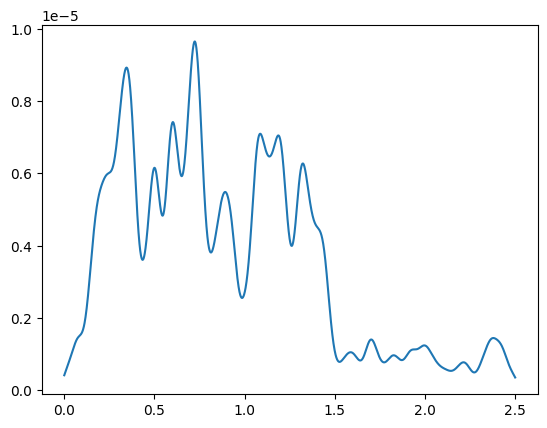

In [46]:
import numpy as np
import librosa
import librosa.display
import soundfile as sf
from scipy.signal import chirp

# === Choose the emotion you want to synthesize ===
emotion = 'SAD'  # Change to 'SAD', 'HAPPY', 'DISGUST', 'ANGRY', 'FEAR', 'NEUTRAL'

# === Parameters ===
duration = 2.0
sr = 22050
n_fft = 2048
hop_length = 512
n_mfcc = 20
n_frames = int(duration * sr / hop_length)

# === Gaussian Function ===
def gaussian(x, mu, sigma, A=1.0):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# === Saliency Curve (Replace with your real one) ===
sal = np.load(f"KDE_vals/{emotion.lower()}.npz")
saliency_x = sal['time']
saliency_y = sal['kde_scaled']
saliency_curve = np.interp(frame_times, saliency_x, saliency_y)
# saliency_curve = (saliency_curve - saliency_curve.min()) / (saliency_curve.max() - saliency_curve.min()) 

plt.plot(saliency_x, saliency_y)
# === Frame-level time axis ===
frame_times = np.linspace(0, duration, n_frames)

# === Load parameters from emotion_data ===
rmse_base = gaussian(frame_times, duration / 2, duration * 0.2, 1.0)
rmse_curve = rmse_base * edata['RMSE_mean'] * (1 + saliency_curve)

zcr_base = gaussian(frame_times, duration / 2, duration * 0.2, 1.0)
zcr_curve = zcr_base * edata['ZCR_mean'] * (1 + saliency_curve)

mfcc_curves = np.array([
    gaussian(frame_times, duration / 2, duration * 0.2, 1.0) * mean * (1 + saliency_curve)
    for mean in edata['MFCC_means']
])
mfcc_curves = mfcc_curves.T  # Shape: (n_frames, n_mfcc)

# === Reconstruct Mel spectrogram from MFCCs ===
# mfcc_curves = mfcc_curves.T  # shape: (n_frames, n_mfcc)
mel_spec = librosa.feature.inverse.mfcc_to_mel(mfcc_curves.T, n_mels=128, dct_type=2)
S = librosa.feature.inverse.mel_to_stft(mel_spec, sr=sr, n_fft=n_fft)

# === Reconstruct waveform from STFT ===
audio = librosa.griffinlim(S, hop_length=hop_length)

# === Apply RMSE as amplitude envelope ===
audio_frames = np.array_split(audio, n_frames)
for i, frame in enumerate(audio_frames):
    audio_frames[i] = frame * rmse_curve[i]
audio = np.concatenate(audio_frames)

# === Normalize and save ===
audio /= np.max(np.abs(audio))
sf.write(f"audio_synth/{emotion.lower()}_gaussian_synth.wav", audio, sr)
print(f"Audio saved as '{emotion.lower()}_gaussian_synth.wav'")
outtt = f"{emotion.lower()}_gaussian_synth.wav"
prediction(outtt)


In [47]:
import numpy as np
import librosa
import sounddevice as sd

# Audio parameters
sample_rate = 44100
duration = 2.0
t = np.linspace(0, duration, int(sample_rate * duration))

# Gaussian envelope for saliency curve
envelope = np.exp(-((t - duration/2)**2) / (duration/4)**2)

# Function to generate audio for an emotion
def generate_emotion_audio(emotion_data, emotion_name):
    # Extract features
    zcr_mean = emotion_data[emotion_name]['ZCR_mean']
    rmse_mean = emotion_data[emotion_name]['RMSE_mean']
    mfcc_means = emotion_data[emotion_name]['MFCC_means']
    
    # Generate base signal (white noise for simplicity)
    signal = np.random.randn(len(t))
    
    # Apply ZCR influence (approximate by mixing with a high-frequency component)
    freq = zcr_mean * sample_rate / 2  # Rough approximation
    high_freq_signal = np.sin(2 * np.pi * freq * t)
    signal = (1 - zcr_mean) * signal + zcr_mean * high_freq_signal
    
    # Apply RMSE (amplitude scaling)
    signal = signal * rmse_mean * envelope
    
    # Approximate MFCC influence (spectral shaping with a simple filter)
    # MFCCs are complex, so we use the first few to shape a low-pass filter
    cutoff = 1000 + (mfcc_means[0] + 400) * 10  # Rough mapping
    signal = librosa.effects.preemphasis(signal, coef=0.97)  # Simple spectral shaping
    
    # Normalize
    signal = signal / np.max(np.abs(signal)) * 0.5
    
    return signal

# Generate and play audio for each emotion
for emotion in emotion_data.keys():
    print(f"Generating audio for {emotion}...")
    audio = generate_emotion_audio(emotion_data, emotion)
    
    # Play audio (uncomment to play)
    # sd.play(audio, sample_rate)
    # sd.wait()
    
    # Optionally save to file
    librosa.output.write_wav(f"{emotion}.wav", audio, sample_rate)

print("Audio generation complete.")

ModuleNotFoundError: No module named 'sounddevice'